# CLASSIFICATION OF LONG BONE FRACTURE SEVERITY LEVELS USING DEEP LEARNING

This notebook implements a deep learning pipeline for classifying long bone X-ray images into three classes:

- Healthy bone
- Simple fracture
- Wedge/Complex fracture

The implementation includes:

- Dataset inspection and visualization
- Data preprocessing and augmentation
- A custom CNN model
- Three pretrained CNN models:
  - ResNet50
  - MobileNetV2
  - VGG19
- Model training and validation
- Testing and evaluation
- Performance comparison



#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import Libraries

The following libraries are used for:

- deep learning: PyTorch and TorchVision
- numerical operations: NumPy
- plotting and visualization: Matplotlib and Seaborn
- image handling: PIL
- evaluation metrics: scikit-learn


In [ ]:
import os
import random
import math
import copy
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cu128


# Reproducibility Setting

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset Path and Structure

In [ ]:
DATA_DIR = "/content/drive/MyDrive/fracture_project/data/all_original"

print("Dataset path:", DATA_DIR)
print("Folders found:", os.listdir(DATA_DIR))

Dataset path: /content/drive/MyDrive/fracture_project/data/all_original
Folders found: ['Simple', 'Wedge_Complex', 'Healthy']


In [ ]:
# Display number of images per class
class_counts = {}
supported_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        count = sum(
            1 for f in os.listdir(class_path)
            if f.lower().endswith(supported_ext)
        )
        class_counts[class_name] = count

print("Number of images per class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

print("Total images:", sum(class_counts.values()))

Number of images per class:
Healthy: 1203
Simple: 1211
Wedge_Complex: 1173
Total images: 3587


# Dataset Inspection and Visualization

In [ ]:
def get_image_paths_by_class(data_dir):
    image_paths = defaultdict(list)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.lower().endswith(supported_ext):
                    image_paths[class_name].append(os.path.join(class_path, fname))
    return image_paths

image_paths_by_class = get_image_paths_by_class(DATA_DIR)
list(image_paths_by_class.keys())

['Healthy', 'Simple', 'Wedge_Complex']

Show sample images from each class

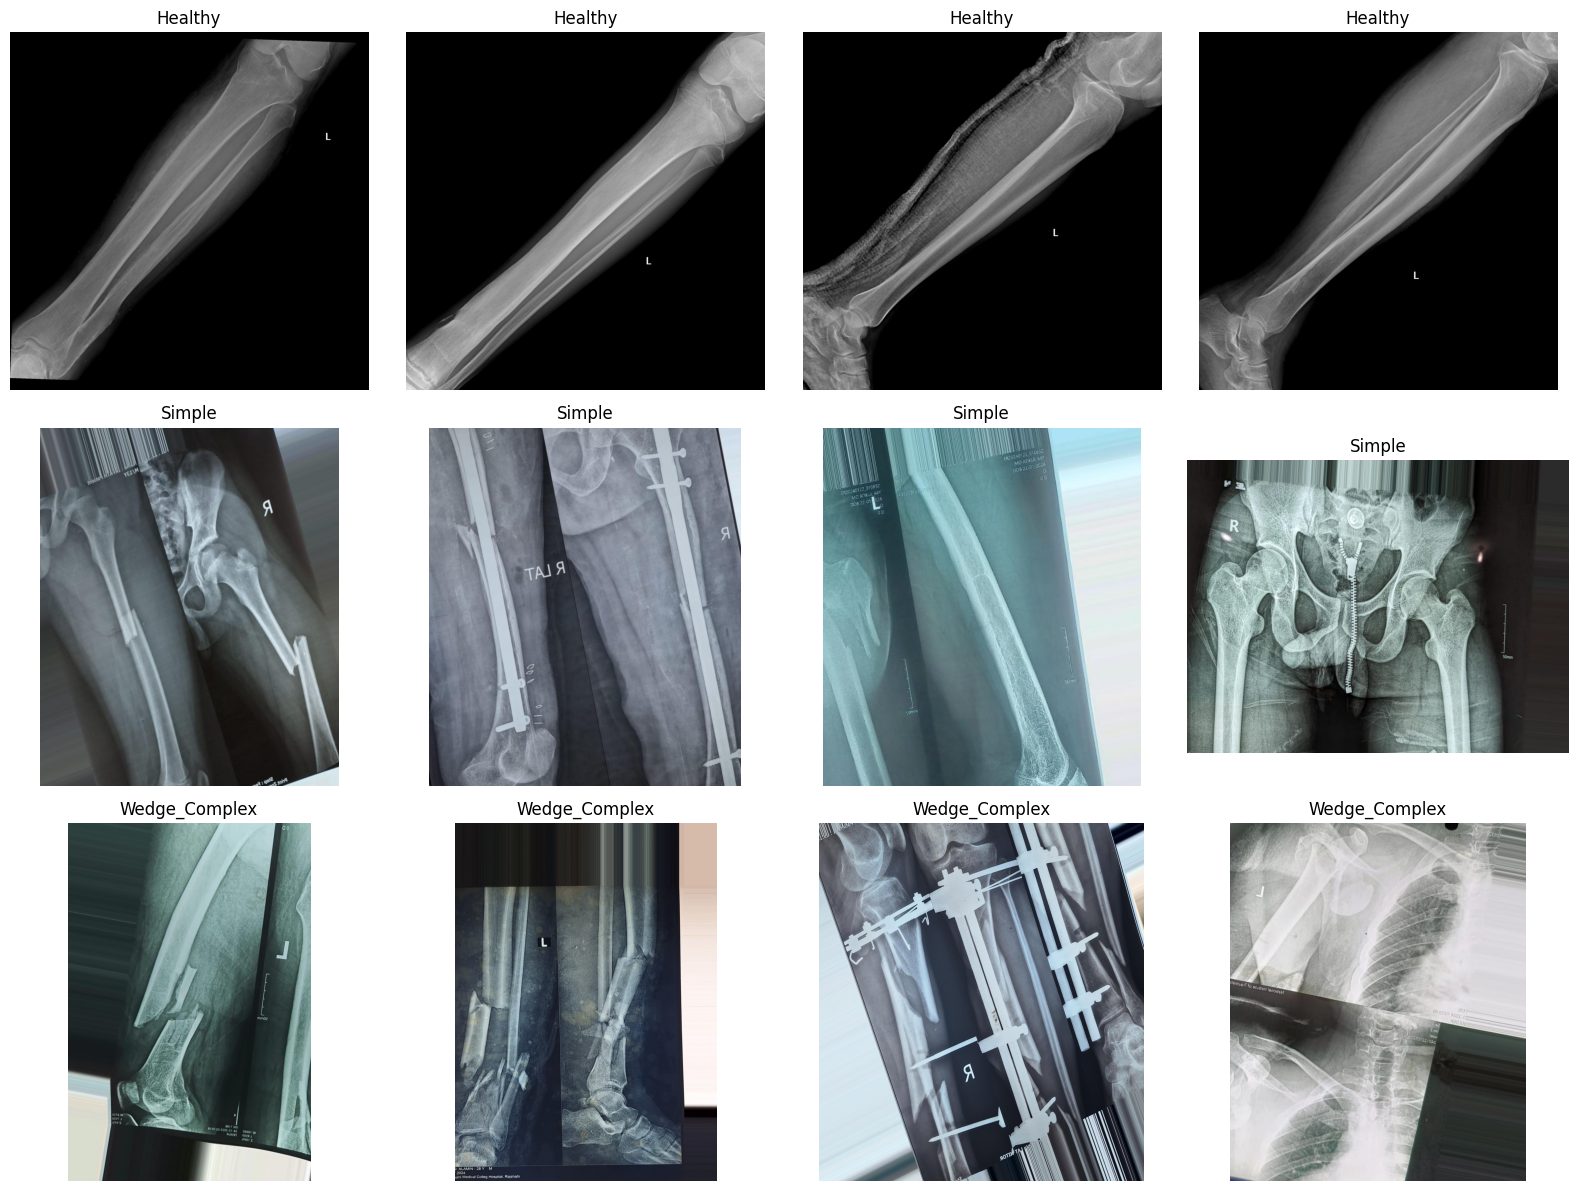

In [ ]:
def show_sample_images(image_paths_by_class, samples_per_class=4):
    classes = sorted(image_paths_by_class.keys())
    plt.figure(figsize=(4 * samples_per_class, 4 * len(classes)))

    plot_idx = 1
    for class_name in classes:
        samples = random.sample(
            image_paths_by_class[class_name],
            min(samples_per_class, len(image_paths_by_class[class_name]))
        )
        for img_path in samples:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(len(classes), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_sample_images(image_paths_by_class, samples_per_class=4)

Class distribution plot

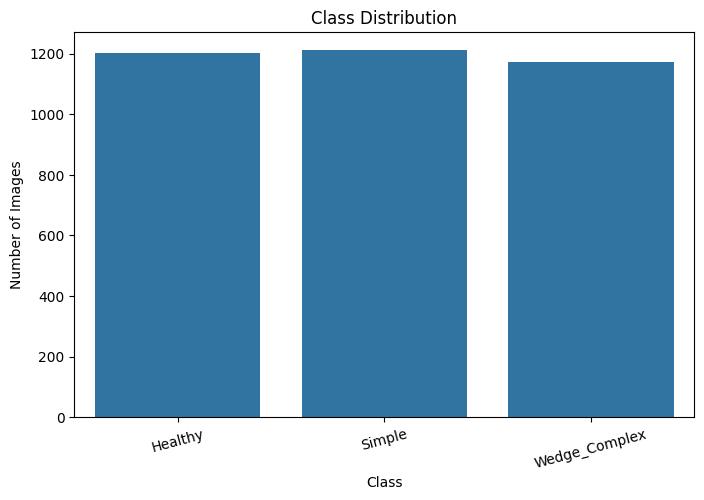

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()

# Data Preprocessing and Augmentation

The images are preprocessed before being fed into the neural network.

The preprocessing steps include:
- resizing images to 224 × 224
- converting images to tensors
- normalizing pixel values

Data augmentation is applied **only to the training set**.
This helps improve generalization by creating random variations of training images.

Augmentation methods used:
- random resized crop
- random horizontal flip
- random rotation
- brightness/contrast adjustment

Validation and test images are not augmented.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 3
EPOCHS = 25
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create Train/Validation/Test Splits

The dataset is split into:

- Training set: 70%
- Validation set: 15%
- Test set: 15%

The same split is used for all models to ensure fair comparison.

In [ ]:
base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes

print("Class names:", class_names)
print("Class to index mapping:", base_dataset.class_to_idx)
print("Total images:", len(base_dataset))

Class names: ['Healthy', 'Simple', 'Wedge_Complex']
Class to index mapping: {'Healthy': 0, 'Simple': 1, 'Wedge_Complex': 2}
Total images: 3587


In [ ]:
total_size = len(base_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

indices = list(range(total_size))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

print("Train size:", len(train_indices))
print("Validation size:", len(val_indices))
print("Test size:", len(test_indices))

Train size: 2510
Validation size: 538
Test size: 539


In [ ]:
# Create two datasets with different transforms
train_dataset_full = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset = Subset(eval_dataset_full, val_indices)
test_dataset = Subset(eval_dataset_full, test_indices)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders created successfully.")

DataLoaders created successfully.


# Denormalization Helper for Visualization

Images are normalized before training; hence, they are denormalized before displaying them.
The following helper function converts tensors back into displayable image format.

In [ ]:
def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

Device Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Custom CNN Model Architecture

A custom Convolutional Neural Network (CNN) was designed to classify long bone X-ray images into three fracture severity categories:

- Healthy bone  
- Simple fracture  
- Wedge/Complex fracture  

The model processes input images of size **224 × 224** and learns hierarchical visual features that help distinguish between normal bone structure and different fracture patterns.

### Architecture Design

The custom CNN consists of several convolutional blocks that progressively extract features from the X-ray images. Each block includes:

- **Convolution layers** to learn spatial features from the images  
- **Batch Normalization** to stabilize and accelerate training  
- **ReLU activation** to introduce non-linearity  
- **Max Pooling** to reduce spatial dimensions and retain important features  

As the network depth increases, the number of feature channels increases, allowing the model to learn more complex fracture-related patterns.

After feature extraction, the resulting feature maps are flattened and passed through **fully connected layers** for classification. A **Dropout layer** is used before the final layer to reduce overfitting.

### Output Layer

The final layer contains **three neurons**, corresponding to the three fracture classes.

The model is trained using **CrossEntropyLoss** and optimized using the **Adam optimizer**.


In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#Pretrained Model Builder Functions

The following pretrained models will be compared:

- ResNet18
- MobileNetV2
- VGG19

For each pretrained model:
- pretrained weights are loaded
- the final classification layer is replaced
- the model is fine-tuned for the 3 fracture classes

In [ ]:
def build_custom_cnn(num_classes=3):
    return CustomCNN(num_classes=num_classes)

def build_resnet50(num_classes=3):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_mobilenet_v2(num_classes=3):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def build_vgg19(num_classes=3):
    model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model

In [ ]:
model_builders = {
    "CustomCNN": build_custom_cnn,
    "ResNet50": build_resnet50,
    "MobileNetV2": build_mobilenet_v2,
    "VGG19": build_vgg19
}

#Loss Function, Optimizer, and Training Utilities

All models are trained using the same pipeline:

- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Number of epochs: 25

During training, the following are tracked:
- training loss
- validation loss
- training accuracy
- validation accuracy

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
def calculate_epoch_metrics(outputs, labels):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct, total

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct, total = calculate_epoch_metrics(outputs, labels)
        running_correct += correct
        running_total += total

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            correct, total = calculate_epoch_metrics(outputs, labels)
            running_correct += correct
            running_total += total

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_one_epoch(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 50)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

#Train All Models

The following cell trains all four models using the same dataset split and training settings.

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/fracture_project/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Models will be saved to:", SAVE_DIR)

Models will be saved to: /content/drive/MyDrive/fracture_project/saved_models


In [ ]:
trained_models = {}
training_histories = {}
model_test_results = {}

for model_name, builder in model_builders.items():
    print(f"\nTraining model: {model_name}")

    model = builder(num_classes=NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS
    )

    trained_models[model_name] = model
    training_histories[model_name] = history

    # SAVE MODEL AFTER TRAINING
    save_path = os.path.join(SAVE_DIR, f"{model_name}_model.pth")
    torch.save(model.state_dict(), save_path)

    print(f"{model_name} saved at {save_path}")


Training model: CustomCNN
Epoch 1/25
Train Loss: 0.8017 | Train Acc: 0.6821
Val Loss:   0.4500 | Val Acc:   0.7695
--------------------------------------------------
Epoch 2/25
Train Loss: 0.4783 | Train Acc: 0.7454
Val Loss:   0.4762 | Val Acc:   0.7230
--------------------------------------------------
Epoch 3/25
Train Loss: 0.4334 | Train Acc: 0.7689
Val Loss:   0.4118 | Val Acc:   0.7900
--------------------------------------------------
Epoch 4/25
Train Loss: 0.4283 | Train Acc: 0.7625
Val Loss:   0.4466 | Val Acc:   0.7565
--------------------------------------------------
Epoch 5/25
Train Loss: 0.4304 | Train Acc: 0.7725
Val Loss:   0.3906 | Val Acc:   0.7900
--------------------------------------------------
Epoch 6/25
Train Loss: 0.4013 | Train Acc: 0.7892
Val Loss:   0.3891 | Val Acc:   0.7937
--------------------------------------------------
Epoch 7/25
Train Loss: 0.4137 | Train Acc: 0.7781
Val Loss:   0.4018 | Val Acc:   0.7937
--------------------------------------------

100%|██████████| 97.8M/97.8M [00:00<00:00, 251MB/s]


Epoch 1/25
Train Loss: 0.4784 | Train Acc: 0.7829
Val Loss:   0.2642 | Val Acc:   0.8903
--------------------------------------------------
Epoch 2/25
Train Loss: 0.1969 | Train Acc: 0.9203
Val Loss:   0.2105 | Val Acc:   0.9126
--------------------------------------------------
Epoch 3/25
Train Loss: 0.1077 | Train Acc: 0.9629
Val Loss:   0.0633 | Val Acc:   0.9833
--------------------------------------------------
Epoch 4/25
Train Loss: 0.0614 | Train Acc: 0.9821
Val Loss:   0.0552 | Val Acc:   0.9814
--------------------------------------------------
Epoch 5/25
Train Loss: 0.0553 | Train Acc: 0.9833
Val Loss:   0.0637 | Val Acc:   0.9796
--------------------------------------------------
Epoch 6/25
Train Loss: 0.0343 | Train Acc: 0.9904
Val Loss:   0.0326 | Val Acc:   0.9907
--------------------------------------------------
Epoch 7/25
Train Loss: 0.0272 | Train Acc: 0.9912
Val Loss:   0.0380 | Val Acc:   0.9926
--------------------------------------------------
Epoch 8/25
Train Los

100%|██████████| 13.6M/13.6M [00:00<00:00, 227MB/s]


Epoch 1/25
Train Loss: 0.5850 | Train Acc: 0.7582
Val Loss:   0.3742 | Val Acc:   0.8513
--------------------------------------------------
Epoch 2/25
Train Loss: 0.3352 | Train Acc: 0.8490
Val Loss:   0.2710 | Val Acc:   0.8829
--------------------------------------------------
Epoch 3/25
Train Loss: 0.2335 | Train Acc: 0.9068
Val Loss:   0.1884 | Val Acc:   0.9257
--------------------------------------------------
Epoch 4/25
Train Loss: 0.1541 | Train Acc: 0.9458
Val Loss:   0.1273 | Val Acc:   0.9517
--------------------------------------------------
Epoch 5/25
Train Loss: 0.0986 | Train Acc: 0.9697
Val Loss:   0.1031 | Val Acc:   0.9647
--------------------------------------------------
Epoch 6/25
Train Loss: 0.0705 | Train Acc: 0.9797
Val Loss:   0.0739 | Val Acc:   0.9721
--------------------------------------------------
Epoch 7/25
Train Loss: 0.0717 | Train Acc: 0.9753
Val Loss:   0.0799 | Val Acc:   0.9647
--------------------------------------------------
Epoch 8/25
Train Los

100%|██████████| 548M/548M [00:01<00:00, 338MB/s]


Epoch 1/25
Train Loss: 0.5087 | Train Acc: 0.7175
Val Loss:   0.4298 | Val Acc:   0.7881
--------------------------------------------------
Epoch 2/25
Train Loss: 0.3807 | Train Acc: 0.8024
Val Loss:   0.3519 | Val Acc:   0.8271
--------------------------------------------------
Epoch 3/25
Train Loss: 0.3866 | Train Acc: 0.8024
Val Loss:   0.3638 | Val Acc:   0.8494
--------------------------------------------------
Epoch 4/25
Train Loss: 0.3397 | Train Acc: 0.8398
Val Loss:   0.3137 | Val Acc:   0.8736
--------------------------------------------------
Epoch 5/25
Train Loss: 0.2832 | Train Acc: 0.8693
Val Loss:   0.2584 | Val Acc:   0.9033
--------------------------------------------------
Epoch 6/25
Train Loss: 0.2710 | Train Acc: 0.8801
Val Loss:   0.2725 | Val Acc:   0.8978
--------------------------------------------------
Epoch 7/25
Train Loss: 0.2412 | Train Acc: 0.9012
Val Loss:   0.2285 | Val Acc:   0.9071
--------------------------------------------------
Epoch 8/25
Train Los

# Visualization of Training Results

For each model, the following plots are displayed:
- training accuracy vs validation accuracy
- training loss vs validation loss


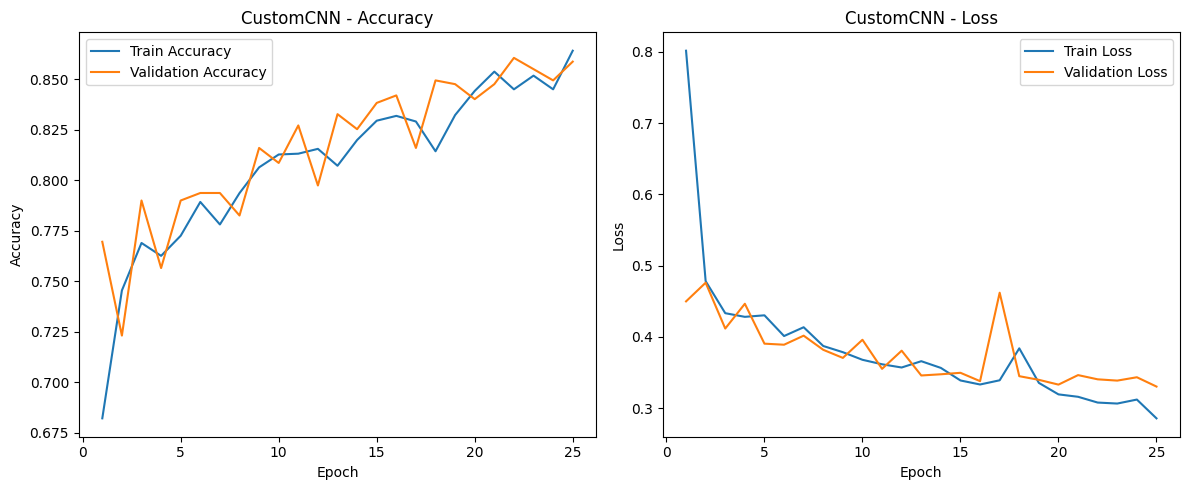

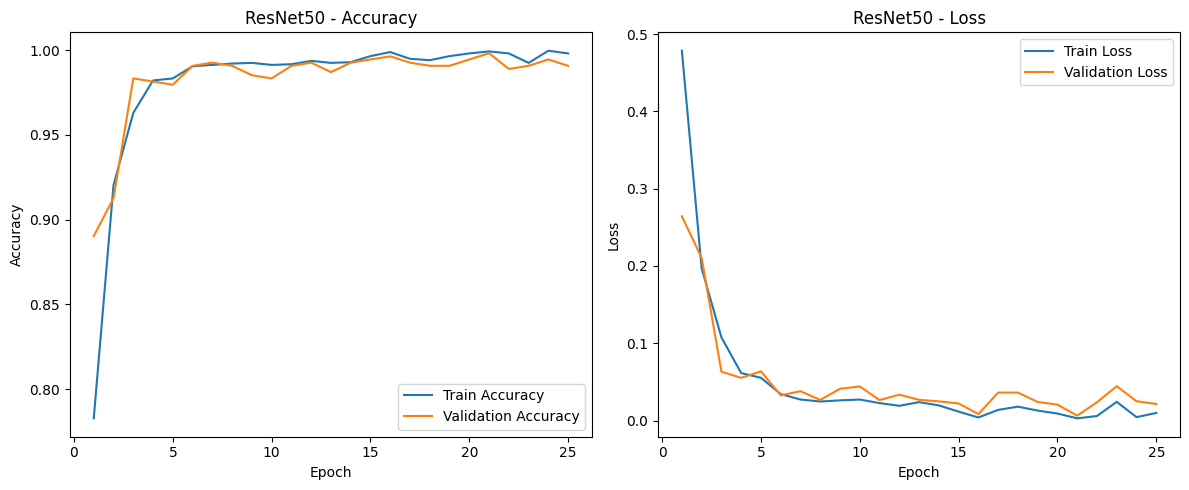

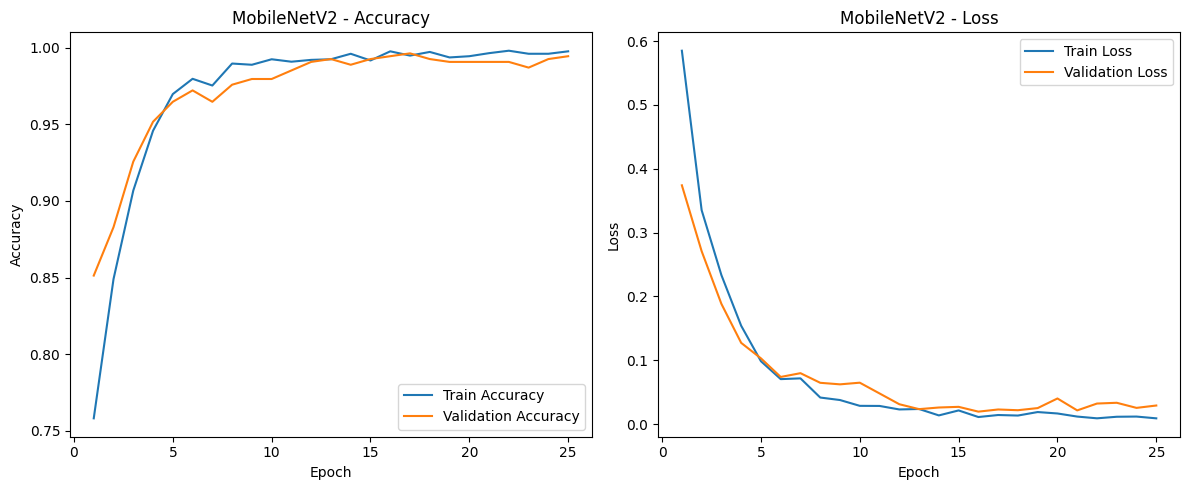

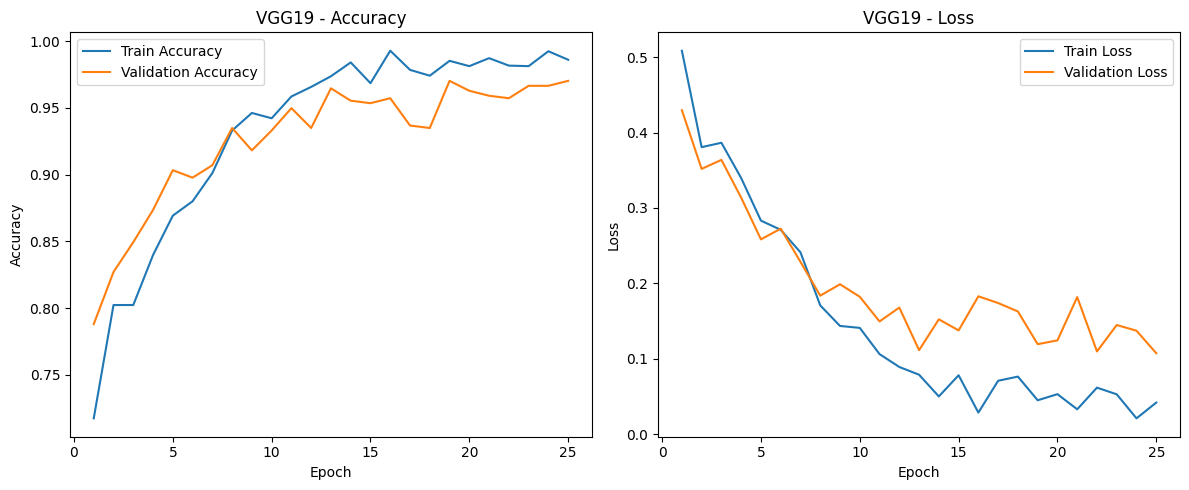

In [ ]:
def plot_training_history(history, model_name):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

for model_name, history in training_histories.items():
    plot_training_history(history, model_name)

# Test Evaluation Metrics

Each trained model is evaluated on the unseen test dataset.

The following metrics are computed:
- Accuracy
- Precision
- Recall
- F1-score

In [ ]:
def evaluate_model_on_test(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

In [ ]:
for model_name, model in trained_models.items():
    results = evaluate_model_on_test(model, test_loader, device)
    model_test_results[model_name] = results

    print(f"\nTest Results - {model_name}")
    print(f"Accuracy : {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall   : {results['recall']:.4f}")
    print(f"F1 Score : {results['f1']:.4f}")


Test Results - CustomCNN
Accuracy : 0.8089
Precision: 0.8084
Recall   : 0.8089
F1 Score : 0.8055

Test Results - ResNet50
Accuracy : 0.9963
Precision: 0.9963
Recall   : 0.9963
F1 Score : 0.9963

Test Results - MobileNetV2
Accuracy : 0.9981
Precision: 0.9982
Recall   : 0.9981
F1 Score : 0.9981

Test Results - VGG19
Accuracy : 0.9740
Precision: 0.9742
Recall   : 0.9740
F1 Score : 0.9740


# Confusion Matrix

A confusion matrix is used to analyze classification performance class by class.

Rows represent the true labels.  
Columns represent the predicted labels.

In [ ]:
import pandas as pd

def plot_confusion_matrix(cm, class_names, title):

    cm_df = pd.DataFrame(
        cm,
        index=[f"True: {c}" for c in class_names],
        columns=[f"Pred: {c}" for c in class_names]
    )

    print(f"\n{title}")
    display(cm_df)

for model_name, results in model_test_results.items():
    plot_confusion_matrix(results["confusion_matrix"], class_names, f"{model_name} - Confusion Matrix")


CustomCNN - Confusion Matrix


,Pred: Healthy,Pred: Simple,Pred: Wedge_Complex
True: Healthy,172,0,1
True: Simple,0,149,35
True: Wedge_Complex,8,59,115



ResNet50 - Confusion Matrix


,Pred: Healthy,Pred: Simple,Pred: Wedge_Complex
True: Healthy,173,0,0
True: Simple,0,182,2
True: Wedge_Complex,0,0,182



MobileNetV2 - Confusion Matrix


,Pred: Healthy,Pred: Simple,Pred: Wedge_Complex
True: Healthy,173,0,0
True: Simple,0,184,0
True: Wedge_Complex,0,1,181



VGG19 - Confusion Matrix


,Pred: Healthy,Pred: Simple,Pred: Wedge_Complex
True: Healthy,173,0,0
True: Simple,0,179,5
True: Wedge_Complex,0,9,173


# Classification Report for Each Model

In [ ]:
for model_name, results in model_test_results.items():
    print(f"\nClassification Report - {model_name}")
    print(classification_report(results["labels"], results["preds"], target_names=class_names, zero_division=0))


Classification Report - CustomCNN
               precision    recall  f1-score   support

      Healthy       0.96      0.99      0.97       173
       Simple       0.72      0.81      0.76       184
Wedge_Complex       0.76      0.63      0.69       182

     accuracy                           0.81       539
    macro avg       0.81      0.81      0.81       539
 weighted avg       0.81      0.81      0.81       539


Classification Report - ResNet50
               precision    recall  f1-score   support

      Healthy       1.00      1.00      1.00       173
       Simple       1.00      0.99      0.99       184
Wedge_Complex       0.99      1.00      0.99       182

     accuracy                           1.00       539
    macro avg       1.00      1.00      1.00       539
 weighted avg       1.00      1.00      1.00       539


Classification Report - MobileNetV2
               precision    recall  f1-score   support

      Healthy       1.00      1.00      1.00       173
       

# Comparison Table

In [ ]:
comparison_rows = []
for model_name, results in model_test_results.items():
    comparison_rows.append([
        model_name,
        results["accuracy"],
        results["precision"],
        results["recall"],
        results["f1"]
    ])

import pandas as pd
comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2,0.998145,0.998155,0.998145,0.998145
1,ResNet50,0.996289,0.996330,0.996289,0.996289
2,VGG19,0.974026,0.974173,0.974026,0.974021
3,CustomCNN,0.808905,0.808401,0.808905,0.805515


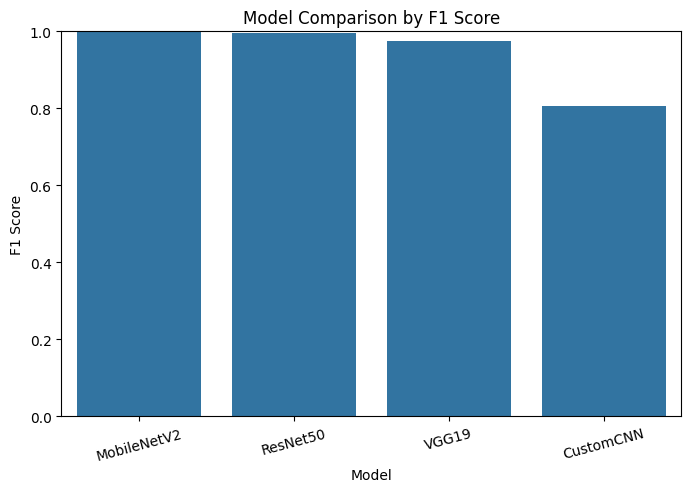

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="F1 Score")
plt.title("Model Comparison by F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

# Classified examples



In [ ]:
best_model = trained_models["MobileNetV2"]

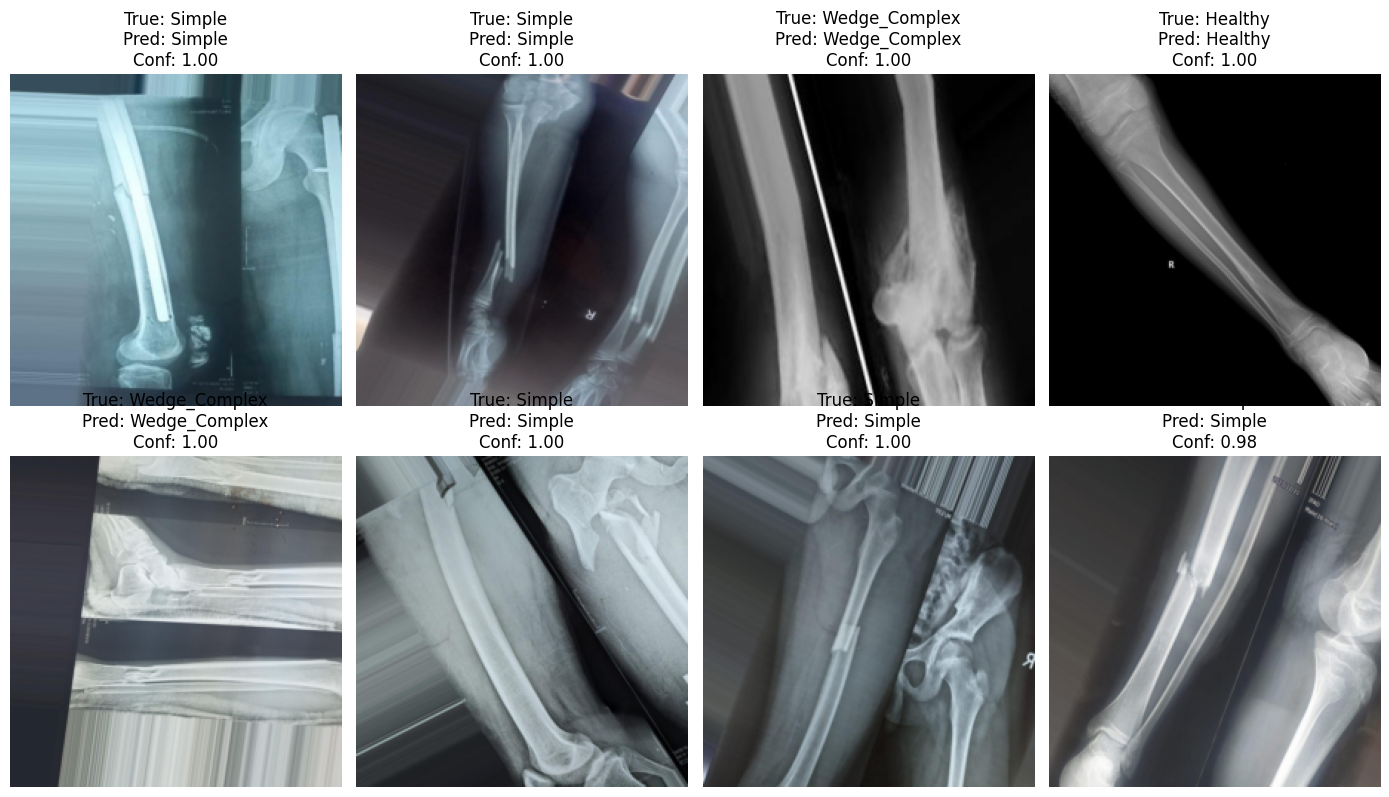

In [ ]:
def show_classified_images(model, dataset, class_names, device, num_images=8):

    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(14,8))

    with torch.no_grad():
        for i, idx in enumerate(indices):

            image, true_label = dataset[idx]

            input_tensor = image.unsqueeze(0).to(device)

            output = model(input_tensor)
            probs = F.softmax(output, dim=1)

            pred_label = torch.argmax(probs, dim=1).item()
            confidence = probs[0][pred_label].item()

            plt.subplot(2, math.ceil(num_images/2), i+1)

            plt.imshow(denormalize_image(image))
            plt.axis("off")

            plt.title(
                f"True: {class_names[true_label]}\n"
                f"Pred: {class_names[pred_label]}\n"
                f"Conf: {confidence:.2f}"
            )

    plt.tight_layout()
    plt.show()




show_classified_images(best_model, test_dataset, class_names, device, num_images=8)

# Conclusion

This notebook implemented a deep learning framework for classifying long bone X-ray images into three classes:

- Healthy bone
- Simple fracture
- Wedge/Complex fracture

A custom CNN model and three pretrained CNN architectures (ResNet50, MobileNetV2, and VGG19) were trained and evaluated using the same dataset split and preprocessing pipeline.

The comparison of test performance showed that the best-performing model was MobileNetV2, achieving the highest values in terms of accuracy, precision, recall, and F1 score.

Key observations:
- Pretrained models generally performed better than the custom CNN due to transfer learning from large-scale image datasets.
- The custom CNN provided a useful baseline but may require more tuning or more data to match pretrained performance.
- Confusion matrix analysis showed the main areas of class confusion.
- Visual inspection of predictions confirmed that the model was able to correctly classify many fracture patterns, while some challenging cases remained difficult.

Overall, the results indicate that deep learning is effective for long bone fracture severity classification, and pretrained CNNs are especially promising for this task.